# Opening Range Breakout (ORB) — Signal Research

**Instrument:** QQQ (5-min bars, regular session 9:30–16:00 ET)
**Signal:** Breakout of the opening range (configurable: 5/10/15 min window)
**Entry:** Basic (next bar open) or Advanced (breakout confirmation)
**Stop loss:** Basic (OR extreme), ATR-based, or combined
**Exit:** Stop loss, profit target, or EOD (15:55 ET)

**This notebook:**
1. Defines the signal engine
2. Grid search → optimal signal parameters
3. Generates trades with best params
4. Significance tests (gross & net)
5. Simple equity curve (gross vs net)
6. Saves standardized trades for PM

**Sizing & implementation comparison** → see `ORB_Implementation.ipynb`

## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from itertools import product
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees, calculate_fees_pct
from _shared.metrics import evaluate_strategy, print_metrics
from _shared.plotting import plot_equity_curve, plot_trade_returns, plot_yearly_returns
from _shared.significance import full_significance_report, print_significance_report
from _shared.results import save_trades

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

SYMBOL     = "QQQ"
START_DATE = "2016-01-01"
END_DATE   = "2026-04-01"

STARTING_CAPITAL = 100_000
LEVERAGE         = 1          # Always 1 — leverage is a PM decision
STRATEGY_NAME    = "ORB"
INSTRUMENT       = "QQQ"
BET_SIZE         = 0.85       # For simple equity curve visualization

## 2. Data Fetching

In [3]:
data_dict = fetch_historical_data(
    [SYMBOL], TimeFrame(5, TimeFrameUnit.Minute), START_DATE, END_DATE)

data_raw = data_dict[SYMBOL]

market_open  = pd.to_datetime("09:30:00").time()
market_close = pd.to_datetime("16:00:00").time()
data = data_raw[(data_raw.index.time >= market_open) & (data_raw.index.time < market_close)].copy()

print(f"Raw bars: {len(data_raw):,}")
print(f"Regular session bars: {len(data):,}")
print(f"Date range: {data.index.min()} → {data.index.max()}")

Fetching QQQ...
  456,689 bars
Raw bars: 456,689
Regular session bars: 200,580
Date range: 2016-01-04 09:30:00-05:00 → 2026-03-31 15:55:00-04:00


## 3. Helper Functions

### 3a. Candle aggregation & threshold

In [4]:
def compute_candle(sub_candles):
    """Aggregate multiple bars into a single OHLC candle."""
    return (
        sub_candles.iloc[0]["open"],
        sub_candles["high"].max(),
        sub_candles["low"].min(),
        sub_candles.iloc[-1]["close"],
    )


def above_threshold(close_price, open_price, threshold_pct):
    """Check if opening range movement exceeds threshold (% of open)."""
    movement = abs(close_price - open_price)
    return movement > (threshold_pct / 100) * open_price

### 3b. Entry functions

In [5]:
def basic_entry(day_data, first_candle, open_price, high_price, low_price, close_price):
    """Basic entry: direction from OR, enter at next bar open."""
    if close_price > open_price:
        signal = "long"
    elif close_price < open_price:
        signal = "short"
    else:
        return None, None, None, None

    entry_time = first_candle.index[-1] + timedelta(minutes=5)
    if entry_time not in day_data.index:
        return None, None, None, None
    return signal, entry_time, day_data.loc[entry_time, "open"], day_data[day_data.index >= entry_time]


def advanced_entry(day_data, first_candle, open_price, high_price, low_price, close_price):
    """Advanced entry: wait for OR high/low breakout confirmation."""
    if close_price > open_price:
        signal, target_price = "long", high_price
    elif close_price < open_price:
        signal, target_price = "short", low_price
    else:
        return None, None, None, None

    next_time = first_candle.index[-1] + timedelta(minutes=5)
    next_data = day_data[day_data.index >= next_time]

    for idx, candle in next_data.iterrows():
        if signal == "long" and candle["high"] >= target_price:
            remaining = next_data[next_data.index >= idx + timedelta(minutes=5)]
            return signal, idx, target_price, remaining
        if signal == "short" and candle["low"] <= target_price:
            remaining = next_data[next_data.index >= idx + timedelta(minutes=5)]
            return signal, idx, target_price, remaining
    return None, None, None, None

### 3c. Stop loss

In [6]:
def compute_stop_loss_basic(signal, high_price, low_price, entry_price):
    """Basic stop: OR low (long) or OR high (short)."""
    if signal == "long":
        return low_price, entry_price - low_price
    return high_price, high_price - entry_price


def compute_stop_loss_atr(atr_df, date, signal, entry_price, atr_percent):
    """ATR-based stop."""
    atr_val = atr_df.loc[date, "atr"]
    if atr_val is None or pd.isna(atr_val):
        return None, None
    dist = (atr_percent / 100) * atr_val
    if signal == "long":
        return entry_price - dist, dist
    return entry_price + dist, dist


def compute_stop_loss_combined(atr_df, date, signal, entry_price, atr_percent, high_price, low_price):
    """Combined: basic stop adjusted by ATR offset."""
    atr_val = atr_df.loc[date, "atr"]
    if atr_val is None or pd.isna(atr_val):
        return None, None
    offset = (atr_percent / 100) * atr_val
    if signal == "long":
        sl = low_price - offset
        return sl, entry_price - sl
    sl = high_price + offset
    return sl, sl - entry_price

### 3d. ATR computation

In [7]:
def compute_atr_df(grouped_days):
    """Compute daily TR and ATR-14 (Wilder's smoothing)."""
    prev_close = None
    records = []
    for date, group in grouped_days:
        _, high_d, low_d, close_d = compute_candle(group)
        if prev_close is None:
            prev_close = close_d
            records.append({"date": date, "tr": np.nan, "atr": np.nan})
            continue
        tr = max(abs(high_d - low_d), abs(high_d - prev_close), abs(low_d - prev_close))
        records.append({"date": date, "tr": tr, "atr": np.nan})
        prev_close = close_d

    atr_df = pd.DataFrame(records).set_index("date")
    period = 14
    tr_vals = atr_df["tr"].dropna()
    if len(tr_vals) >= period:
        atr_df.loc[tr_vals.index[period - 1], "atr"] = tr_vals.iloc[:period].mean()
        for i in range(period, len(tr_vals)):
            idx = tr_vals.index[i]
            prev_idx = tr_vals.index[i - 1]
            prev_atr = atr_df.loc[prev_idx, "atr"]
            if pd.notna(prev_atr):
                atr_df.loc[idx, "atr"] = (prev_atr * (period - 1) + tr_vals.iloc[i]) / period
    return atr_df

## 4. Signal Engine

Generates raw trades — **no position sizing, no equity tracking.**
The `pct_return_gross` is the raw price move, independent of leverage or account size.

In [8]:
def generate_signals(df, window_size, profit_target_multiplier,
                     stop_loss_strategy, atr_percent, threshold, entry_mode):
    """
    Generate raw ORB trades — signal only, no sizing.

    Returns DataFrame with standardized columns:
        entry_time, exit_time, direction, instrument, entry_price,
        exit_price, pct_return_gross, exit_reason, stop_price
    """
    trades = []

    df_copy = df.copy()
    df_copy["date"] = pd.to_datetime(df_copy.index.date)
    grouped = df_copy.groupby("date")

    atr_df = None
    if stop_loss_strategy in ("atr", "basic+atr"):
        atr_df = compute_atr_df(grouped)

    n_bars = window_size // 5

    for date, group in grouped:
        first_candle = group.iloc[:n_bars]
        if len(first_candle) < n_bars:
            continue
        open_p, high_p, low_p, close_p = compute_candle(first_candle)

        if not above_threshold(close_p, open_p, threshold):
            continue

        if entry_mode == "basic":
            signal, entry_time, entry_price, remaining = basic_entry(
                group, first_candle, open_p, high_p, low_p, close_p)
        elif entry_mode == "advanced":
            signal, entry_time, entry_price, remaining = advanced_entry(
                group, first_candle, open_p, high_p, low_p, close_p)
        else:
            continue

        if signal is None or entry_time is None or remaining is None or len(remaining) == 0:
            continue

        if stop_loss_strategy == "basic":
            stop_loss, risk = compute_stop_loss_basic(signal, high_p, low_p, entry_price)
        elif stop_loss_strategy == "atr":
            stop_loss, risk = compute_stop_loss_atr(atr_df, date, signal, entry_price, atr_percent)
        elif stop_loss_strategy == "basic+atr":
            stop_loss, risk = compute_stop_loss_combined(
                atr_df, date, signal, entry_price, atr_percent, high_p, low_p)
        else:
            continue

        if risk is None or risk <= 0:
            continue

        if profit_target_multiplier is not None:
            if signal == "long":
                target = entry_price + profit_target_multiplier * risk
            else:
                target = entry_price - profit_target_multiplier * risk
        else:
            target = None

        exit_price = exit_time = exit_reason = None
        for idx, candle in remaining.iterrows():
            if signal == "long" and candle["low"] <= stop_loss:
                exit_price, exit_time, exit_reason = stop_loss, idx, "stop"
                break
            if signal == "short" and candle["high"] >= stop_loss:
                exit_price, exit_time, exit_reason = stop_loss, idx, "stop"
                break
            if target is not None:
                if signal == "long" and candle["high"] >= target:
                    exit_price, exit_time, exit_reason = target, idx, "target"
                    break
                if signal == "short" and candle["low"] <= target:
                    exit_price, exit_time, exit_reason = target, idx, "target"
                    break

        if exit_price is None:
            exit_price = remaining["close"].iloc[-1]
            exit_time = remaining.index[-1]
            exit_reason = "eod"

        if signal == "long":
            pct_return_gross = (exit_price - entry_price) / entry_price
        else:
            pct_return_gross = (entry_price - exit_price) / entry_price

        trades.append({
            "entry_time":       entry_time,
            "exit_time":        exit_time + timedelta(minutes=5),
            "direction":        signal,
            "instrument":       INSTRUMENT,
            "entry_price":      round(entry_price, 4),
            "exit_price":       round(exit_price, 4),
            "pct_return_gross": round(pct_return_gross, 6),
            "exit_reason":      exit_reason,
            "stop_price":       round(stop_loss, 4),
        })

    return pd.DataFrame(trades) if trades else pd.DataFrame()

## 5. Parameter Grid Search

Find the best signal parameters before running the full evaluation.
Uses `calculate_fees_pct` for net Sharpe — no sizing needed.

In [9]:
param_grid = {
    "window_size":              [5, 10, 15],
    "profit_target_multiplier": [None],
    "stop_loss_strategy":       ["basic", "atr"],
    "atr_percent":              [2, 5, 10],
    "threshold":                [0, 0.02],
    "entry_mode":               ["basic"],
}

param_keys = list(param_grid.keys())
all_combos = list(product(*param_grid.values()))
print(f"Total combinations: {len(all_combos)}")

grid_results = []
for combo in all_combos:
    params = dict(zip(param_keys, combo))
    if params["stop_loss_strategy"] == "basic" and params["atr_percent"] != param_grid["atr_percent"][0]:
        continue
    try:
        res = generate_signals(data, **params)
        if res.empty:
            continue
        fee_pcts = res.apply(
            lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
        rets = res["pct_return_gross"] - fee_pcts
        n = len(rets)
        wins = (rets > 0).sum()
        total_ret = ((1 + rets).prod() - 1) * 100
        sharpe = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
        eq = STARTING_CAPITAL * (1 + rets).cumprod()
        max_dd = ((eq - eq.expanding().max()) / eq.expanding().max()).min() * 100
        pf = abs(rets[rets > 0].sum() / rets[rets < 0].sum()) if rets[rets < 0].sum() != 0 else np.inf

        grid_results.append({
            **params,
            "Trades": n, "Win Rate": round(wins/n*100, 1),
            "Total Return": round(total_ret, 1),
            "Sharpe": round(sharpe, 2), "Max Drawdown": round(max_dd, 1),
            "Profit Factor": round(pf, 2),
        })
    except Exception:
        pass

grid_df = pd.DataFrame(grid_results)
print(f"Completed: {len(grid_results)}")

Total combinations: 36
Completed: 24


In [10]:
if not grid_df.empty:
    display_cols = ["window_size", "stop_loss_strategy", "atr_percent", "threshold",
                    "Sharpe", "Total Return", "Max Drawdown",
                    "Win Rate", "Profit Factor", "Trades"]
    available = [c for c in display_cols if c in grid_df.columns]
    top = grid_df.sort_values("Sharpe", ascending=False).head(15)
    print("TOP PARAMETER COMBINATIONS (by Sharpe):")
    print("=" * 110)
    print(top[available].to_string(index=False))

    # Best params
    best_row = grid_df.loc[grid_df["Sharpe"].idxmax()]
    print(f"\nBest: window={int(best_row['window_size'])}, stop={best_row['stop_loss_strategy']}, "
          f"atr={best_row['atr_percent']}%, threshold={best_row['threshold']}")

TOP PARAMETER COMBINATIONS (by Sharpe):
 window_size stop_loss_strategy  atr_percent  threshold  Sharpe  Total Return  Max Drawdown  Win Rate  Profit Factor  Trades
           5                atr            5       0.02    0.89          65.3          -8.8      11.2           1.26    2333
           5                atr            5       0.00    0.77          58.8          -8.5      11.0           1.23    2530
           5                atr           10       0.02    0.76          83.4          -9.5      18.5           1.19    2333
           5                atr            2       0.02    0.73          32.6          -8.1       5.7           1.29    2333
           5              basic            2       0.02    0.62          77.3         -13.2      24.6           1.14    2346
           5                atr           10       0.00    0.62          67.7          -9.4      18.3           1.15    2530
          15                atr           10       0.02    0.57          51.6        

### Set Parameters

Set `DEFAULT_PARAMS` based on grid search results (or keep manual choice).
Modify here if the grid search suggests a better combination.

In [11]:
# Set signal parameters — adjust based on grid search results above
DEFAULT_PARAMS = {
    "window_size":              5,
    "profit_target_multiplier": None,
    "stop_loss_strategy":       "atr",
    "atr_percent":              5,
    "threshold":                0.02,
    "entry_mode":               "basic",
}

print(f"Using params: {DEFAULT_PARAMS}")

Using params: {'window_size': 5, 'profit_target_multiplier': None, 'stop_loss_strategy': 'atr', 'atr_percent': 5, 'threshold': 0.02, 'entry_mode': 'basic'}


## 6. Signal Generation & Significance Tests

- **Gross:** Is the entry/exit logic producing positive returns?
- **Net:** Does the signal survive transaction costs?

In [12]:
raw_trades = generate_signals(data, **DEFAULT_PARAMS)
print(f"Total signal trades: {len(raw_trades)}")

# Net returns (no sizing needed)
raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"Avg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# Significance: GROSS
sig_gross = raw_trades[["direction", "pct_return_gross"]].copy()
sig_gross["net_pnl"] = sig_gross["pct_return_gross"]
sig_gross["equity_before"] = 1.0
sig_gross["position"] = sig_gross["direction"]

if len(sig_gross) >= 5:
    report_gross = full_significance_report(sig_gross, strategy_name=f"{STRATEGY_NAME} (gross)")
    print_significance_report(report_gross)

# Significance: NET
sig_net = raw_trades[["direction", "pct_return_net"]].copy()
sig_net["net_pnl"] = sig_net["pct_return_net"]
sig_net["equity_before"] = 1.0
sig_net["position"] = sig_net["direction"]

if len(sig_net) >= 5:
    report_net = full_significance_report(sig_net, strategy_name=f"{STRATEGY_NAME} (net)")
    print_significance_report(report_net)

Total signal trades: 2333
Avg fee: 0.0119% per trade
Avg gross return: 0.0342%
Avg net return: 0.0223%

STATISTICAL SIGNIFICANCE — ORB (gross)

1. t-test (returns > 0)
   Mean return:  0.0342% per trade
   t-statistic:  4.1422
   p-value:      1.8e-05
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   1.3616
   95% CI:            [0.7957, 1.8747]
   % below zero:      0.0%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   1.3616
   p-value:           0.0
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)

STATISTICAL SIGNIFICANCE — ORB (net)

1. t-test (returns > 0)
   Mean return:  0.0223% per trade
   t-statistic:  2.7072
   p-value:      0.003417
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.8899
   95% CI:            [0.2829, 1.4364]
   % below zero:      0.18%
   Significant:       YES

3. Permutation tes

## 7. Simple Equity Curve — Gross vs Net

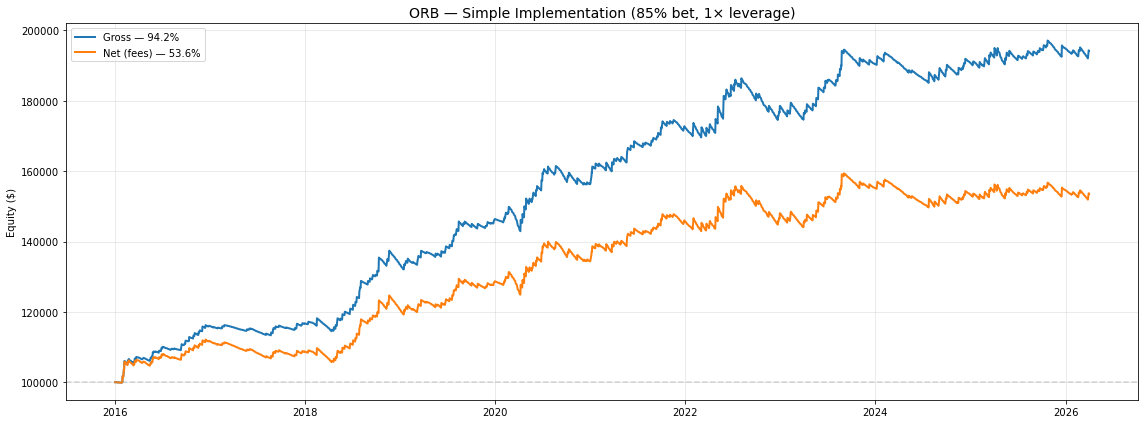

Fee drag: $40,609 (20.9% of gross)


In [13]:
equity_gross = STARTING_CAPITAL
equity_net = STARTING_CAPITAL
gross_curve = [STARTING_CAPITAL]
net_curve = [STARTING_CAPITAL]

for _, trade in raw_trades.iterrows():
    notional_g = equity_gross * BET_SIZE
    notional_n = equity_net * BET_SIZE
    shares_g = int(notional_g / trade["entry_price"])
    shares_n = int(notional_n / trade["entry_price"])

    if trade["direction"] == "long":
        pnl_g = shares_g * (trade["exit_price"] - trade["entry_price"])
        pnl_n = shares_n * (trade["exit_price"] - trade["entry_price"])
    else:
        pnl_g = shares_g * (trade["entry_price"] - trade["exit_price"])
        pnl_n = shares_n * (trade["entry_price"] - trade["exit_price"])

    fees = calculate_fees(shares_n, trade["entry_price"], trade["exit_price"], trade["direction"])

    equity_gross += pnl_g
    equity_net += pnl_n - fees
    gross_curve.append(equity_gross)
    net_curve.append(equity_net)

dates = [pd.Timestamp(START_DATE)] + pd.to_datetime(raw_trades["exit_time"]).dt.tz_localize(None).tolist()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dates, gross_curve, linewidth=2, label=f"Gross — {(gross_curve[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.plot(dates, net_curve, linewidth=2, label=f"Net (fees) — {(net_curve[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"{STRATEGY_NAME} — Simple Implementation ({BET_SIZE:.0%} bet, {LEVERAGE}× leverage)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Fee drag: ${gross_curve[-1] - net_curve[-1]:,.0f} ({(1 - net_curve[-1]/gross_curve[-1])*100:.1f}% of gross)")

## 8. Long vs Short Breakdown

In [14]:
for side in ["long", "short"]:
    subset = raw_trades[raw_trades["direction"] == side]
    if subset.empty:
        continue
    n = len(subset)
    wins = (subset["pct_return_gross"] > 0).sum()
    avg_ret = subset["pct_return_gross"].mean() * 100
    print(f"\n{side.upper()}: {n} trades, WR={wins/n*100:.1f}%, Avg Return={avg_ret:+.3f}%")
    for reason in ["stop", "target", "eod"]:
        r = subset[subset["exit_reason"] == reason]
        if r.empty:
            continue
        print(f"  {reason:<8} — {len(r):3d} trades, avg return: {r['pct_return_gross'].mean()*100:+.3f}%")


LONG: 1214 trades, WR=11.4%, Avg Return=+0.033%
  stop     — 1075 trades, avg return: -0.085%
  eod      — 139 trades, avg return: +0.938%

SHORT: 1119 trades, WR=10.9%, Avg Return=+0.036%
  stop     — 997 trades, avg return: -0.083%
  eod      — 122 trades, avg return: +1.007%


## 9. Save Standardized Trades

Saves raw signal trades for PM consumption. No sizing, no fees baked in.
Run `ORB_Implementation.ipynb` to compare sizing methods.

In [15]:
import os, json

os.makedirs("results", exist_ok=True)

# Standard trades CSV
std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv("results/orb_trades.csv", index=False)
print(f"Saved {len(raw_trades)} standardized trades → results/orb_trades.csv")

# Summary JSON
summary = {
    "strategy":    STRATEGY_NAME,
    "instrument":  INSTRUMENT,
    "portfolio":   "short_term",
    "period":      f"{START_DATE} → {END_DATE}",
    "params":      DEFAULT_PARAMS,
    "trades":      len(raw_trades),
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"],
                  "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"],
                  "tests_passed": report_net["tests_passed"]},
    },
}
with open("results/orb_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"Saved summary → results/orb_summary.json")

print(f"\nNext: run ORB_Implementation.ipynb for sizing comparison")

Saved 2333 standardized trades → results/orb_trades.csv
Saved summary → results/orb_summary.json

Next: run ORB_Implementation.ipynb for sizing comparison
